The purpose of this Jupyter Notebook is to easily visualize the distribution of the Regress LM datasets we are experimenting with.

In [2]:
# Libary imports
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from ast import literal_eval

### Code Regression Dataset Vizzes

In [3]:
# Load dataset
code_regression_dataset = load_dataset("akhauriyash/Code-Regression", split="train")

In [4]:
# Select columns and convert to Pandas DF
code_regression_dataset = code_regression_dataset.select_columns(["target", "space"]) # filter by only these 2 columns since dataset is >4.7 million rows
df = code_regression_dataset.to_pandas()

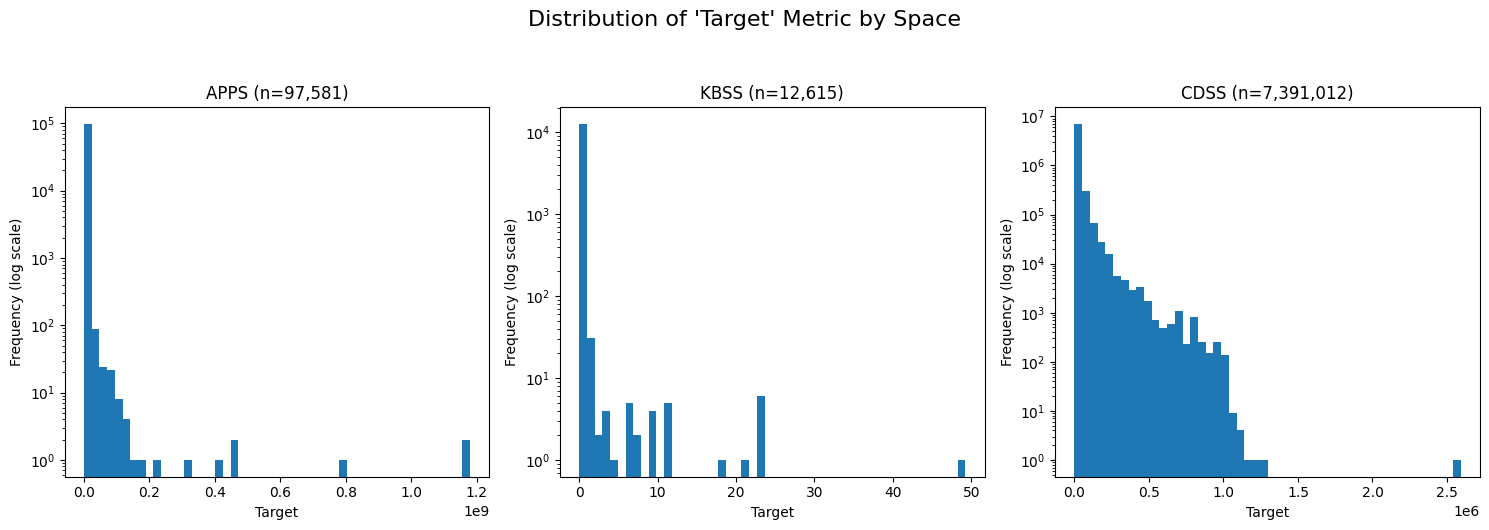

In [5]:
# Set up plotting grid
spaces = ["APPS", "KBSS", "CDSS"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle("Distribution of 'Target' Metric by Space", fontsize=16, y=1.05)

for ax, space in zip(axes, spaces):
    # Filter the target values for the specific space and drop missing values
    subset = df[df["space"] == space]["target"].dropna()
    
    # Plot histogram
    ax.hist(subset, bins=50)
    
    # Format histogram
    ax.set_title(f"{space} (n={len(subset):,})") # Add space label
    ax.set_xlabel("Target")
    ax.set_ylabel("Frequency (log scale)")
    ax.set_yscale('log')

plt.tight_layout()

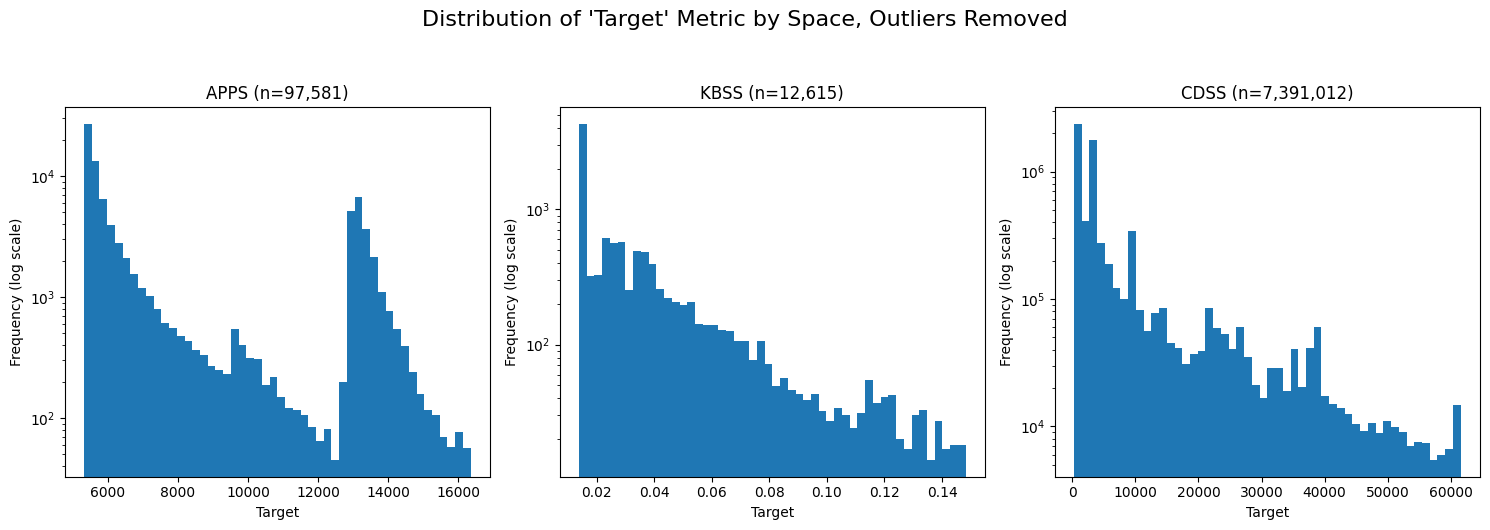

In [6]:
# Plot histogram distributions of each space but clip the top and bottom 1% of extreme outlier

# Set up plotting grid
spaces = ["APPS", "KBSS", "CDSS"]

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=False)
fig.suptitle("Distribution of 'Target' Metric by Space, Outliers Removed", fontsize=16, y=1.05)

for ax, space in zip(axes, spaces):
    # Filter the target values for the specific space and drop missing values
    subset = df[df["space"] == space]["target"].dropna()
    
    # Plot a histogram
    ax.hist(subset, bins=50, range=(subset.quantile(0.05),subset.quantile(0.95)))
    
    # Formatting
    ax.set_title(f"{space} (n={len(subset):,})")
    ax.set_xlabel("Target")
    ax.set_ylabel("Frequency (log scale)")
    ax.set_yscale('log')

plt.tight_layout()

Up Next:

Load dataset w/ metadata, plot against different fields to see if we can find any meaningful spurious correlations to test against.

### Graph Regression Dataset Vizzes

In [ ]:
# Focusing on Code Regression dataset for now!
# Load the dataset
ds = load_dataset("akhauriyash/GraphArch-Regression", split="train")